### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from function_to_normalize_sgrna_lfc import *

In [156]:
read_count = pd.read_csv("./tkov3_data/matrix-reads-by-gRNA-RPE1-drugZ.txt", sep ='\t')
read_count[['gene', 'sgRNA']] = read_count['sgRNA'].str.split('_', n = 1, expand=True)
read_count = read_count.drop(columns=['GENE', 'gene'])
read_count = read_count.rename(columns={'sgRNA':'spacer'})

# filtered out sgRNA with less than 30 reads
read_count = read_count[read_count['RPE1_T0'] > 30]
read_count
list(read_count)

['spacer',
 'RPE1_T0',
 'RPE1_T3A_CTRL_LOPRIMER',
 'RPE1_T3A_CTRL',
 'RPE1_T3A_ENTI_LOPRIMER',
 'RPE1_T3A_ENTI',
 'RPE1_T3A_GEMC',
 'RPE1_T3A_VINC',
 'RPE1_T3B_CTRL',
 'RPE1_T3B_ENTI',
 'RPE1_T3B_GEMC',
 'RPE1_T3B_VINC']

In [145]:
# import library data
library_data = pd.read_csv("../../CRISPR-KO-library-refinement-pipeline/public_crispr_library/tkov3_guide_sequence.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
library_data.shape

(71090, 3)

In [146]:
read_count = pd.merge(read_count, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="sgRNA")
read_count

,,,RPE1_T0,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,492,416,288,275,262,277,286,222,401,216,228
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,258,54,49,38,25,101,28,5,57,52,32
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,164,83,93,33,50,105,39,44,118,33,77
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,487,668,360,462,307,353,278,290,565,193,209
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,190,146,96,24,36,35,59,53,72,22,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,180,356,232,343,281,257,398,206,407,131,201
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,617,484,433,423,418,447,402,373,751,314,407
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,585,455,235,412,331,325,281,202,392,263,208


In [147]:
# we log transformed the raw read counts (log2(counts + 1))

# separate plasmid count into a new column
# plasmid_count = read_count['RPE1_T0']
# plasmid_count

# log transformed read count (without plasmid)
# read_count = read_count.drop(columns=['RPE1_T0'])
log_transformed_read_count = np.log2(read_count + 1)
log_transformed_read_count

,,,RPE1_T0,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,8.945444,8.703904,8.174926,8.108524,8.038919,8.118941,8.164907,7.800900,8.651052,7.761551,7.839204
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,8.016808,5.781360,5.643856,5.285402,4.700440,6.672425,4.857981,2.584963,5.857981,5.727920,5.044394
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,7.366322,6.392317,6.554589,5.087463,5.672425,6.727920,5.321928,5.491853,6.894818,5.087463,6.285402
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,8.930737,9.385862,8.495855,8.854868,8.266787,8.467606,8.124121,8.184875,9.144658,7.599913,7.714246
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,7.577429,7.199672,6.599913,4.643856,5.209453,5.169925,5.906891,5.754888,6.189825,4.523562,4.857981
...,...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,7.499846,8.479780,7.864186,8.426265,8.139551,8.011227,8.640245,7.693487,8.672425,7.044394,7.658211
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,9.271463,8.921841,8.761551,8.727920,8.710806,8.807355,8.654636,8.546894,9.554589,8.299208,8.672425
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,9.194757,8.832890,7.882643,8.689998,8.375039,8.348728,8.139551,7.665336,8.618386,8.044394,7.707359


In [148]:
# normalized the data across cell lines by centering around the median of guides targeting non-essential genes (in this case we can use control genes)
# controls in TKOv3 are EGFP, LacZ, and luciferase
log_transformed_read_count_control = log_transformed_read_count[log_transformed_read_count.index.get_level_values(2).isin(['EGFP', 'LacZ', 'luciferase'])]
log_transformed_read_count_control

,,,RPE1_T0,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,,
sgEGFP_1,TTCAAGTCCGCCATGCCCGA,EGFP,9.938109,9.640245,9.152285,9.038919,9.063395,9.174926,8.353147,8.826548,9.744834,8.965784,8.968667
sgEGFP_10,CAGCTCGATGCGGTTCACCA,EGFP,9.702173,8.276124,8.011227,7.409391,7.707359,8.055282,8.129283,7.515700,8.194757,7.982994,7.312883
sgEGFP_11,GAAGGGCATCGACTTCAAGG,EGFP,8.417853,7.982994,7.238405,7.832890,7.864186,6.942515,7.781360,7.459432,8.228819,7.960002,8.082149
sgEGFP_12,CCTCGAACTTCACCTCGGCG,EGFP,8.603626,8.396605,7.870365,7.924813,7.942515,8.179909,7.774787,7.900867,9.066089,8.194757,8.459432
sgEGFP_13,CTGGACGTAGCCTTCGGGCA,EGFP,10.437752,9.403012,8.774787,9.560333,9.221587,9.131857,9.436712,8.629357,10.043027,9.588715,8.965784
...,...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,7.499846,8.479780,7.864186,8.426265,8.139551,8.011227,8.640245,7.693487,8.672425,7.044394,7.658211
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,9.271463,8.921841,8.761551,8.727920,8.710806,8.807355,8.654636,8.546894,9.554589,8.299208,8.672425
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,9.194757,8.832890,7.882643,8.689998,8.375039,8.348728,8.139551,7.665336,8.618386,8.044394,7.707359


In [149]:
# data were normalized across cell lines by centering around the median of guides targeting control genes (EGFP, LacZ, and luciferase)
median = np.nanmedian(log_transformed_read_count_control)

normalized_read_count = log_transformed_read_count - median
normalized_read_count

,,,RPE1_T0,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,1.125265,0.883725,0.354747,0.288345,0.218740,0.298762,0.344728,-0.019279,0.830873,-0.058628,0.019025
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,0.196629,-2.038819,-2.176323,-2.534777,-3.119739,-1.147754,-2.962198,-5.235216,-1.962198,-2.092259,-2.775785
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.453857,-1.427862,-1.265590,-2.732716,-2.147754,-1.092259,-2.498251,-2.328326,-0.925361,-2.732716,-1.534777
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,1.110558,1.565683,0.675676,1.034689,0.446608,0.647427,0.303942,0.364696,1.324479,-0.220266,-0.105933
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.242750,-0.620507,-1.220266,-3.176323,-2.610726,-2.650254,-1.913288,-2.065291,-1.630354,-3.296617,-2.962198
...,...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,-0.320333,0.659601,0.044007,0.606086,0.319372,0.191048,0.820066,-0.126692,0.852246,-0.775785,-0.161967
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,1.451284,1.101662,0.941372,0.907741,0.890627,0.987176,0.834457,0.726715,1.734410,0.479029,0.852246
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,1.374578,1.012711,0.062464,0.869819,0.554860,0.528549,0.319372,-0.154843,0.798207,0.224215,-0.112820


In [150]:
# compute sgRNA log fold change by subtracting the log-transformed normalized count from the plasmid library
sgrna_lfc = normalized_read_count.drop(columns=['RPE1_T0']).subtract(normalized_read_count['RPE1_T0'], axis=0)
sgrna_lfc

,,,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.241540,-0.770518,-0.836919,-0.906525,-0.826503,-0.780537,-1.144544,-0.294392,-1.183893,-1.106240
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-2.235449,-2.372952,-2.731406,-3.316369,-1.344383,-3.158827,-5.431846,-2.158827,-2.288888,-2.972414
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.974005,-0.811733,-2.278859,-1.693897,-0.638402,-2.044394,-1.874469,-0.471504,-2.278859,-1.080920
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.455125,-0.434882,-0.075869,-0.663951,-0.463132,-0.806616,-0.745862,0.213921,-1.330824,-1.216492
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.377756,-0.977516,-2.933573,-2.367975,-2.407504,-1.670538,-1.822541,-1.387604,-3.053867,-2.719448
...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.979934,0.364340,0.926419,0.639705,0.511381,1.140399,0.193641,1.172579,-0.455452,0.158366
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,-0.349622,-0.509912,-0.543543,-0.560657,-0.464108,-0.616827,-0.724569,0.283126,-0.972255,-0.599038
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.361867,-1.312114,-0.504759,-0.819717,-0.846029,-1.055206,-1.529421,-0.576371,-1.150363,-1.487398


In [151]:
# scaled sgRNA log fold change by centering around the median LFC of guides targeting essential genes
sgrna_lfc_scaled, list_common_essential = scale_essential(sgrna_lfc)
sgrna_lfc_scaled

Scale factor:  2.6708962617499994


,,,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.090434,-0.288487,-0.313348,-0.339408,-0.309448,-0.292238,-0.428524,-0.110222,-0.443257,-0.414183
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-0.836966,-0.888448,-1.022655,-1.241669,-0.503345,-1.182684,-2.033716,-0.808278,-0.856974,-1.112890
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.364673,-0.303918,-0.853219,-0.634205,-0.239022,-0.765434,-0.701813,-0.176534,-0.853219,-0.404703
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.170402,-0.162823,-0.028406,-0.248587,-0.173399,-0.302002,-0.279255,0.080093,-0.498269,-0.455462
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.141434,-0.365988,-1.098348,-0.886585,-0.901384,-0.625460,-0.682371,-0.519528,-1.143387,-1.018178
...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.366893,0.136411,0.346857,0.239510,0.191464,0.426972,0.072500,0.439021,-0.170524,0.059293
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,-0.130901,-0.190914,-0.203506,-0.209913,-0.173765,-0.230944,-0.271283,0.106004,-0.364018,-0.224283
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.135485,-0.491263,-0.188985,-0.306907,-0.316758,-0.395075,-0.572625,-0.215797,-0.430703,-0.556891


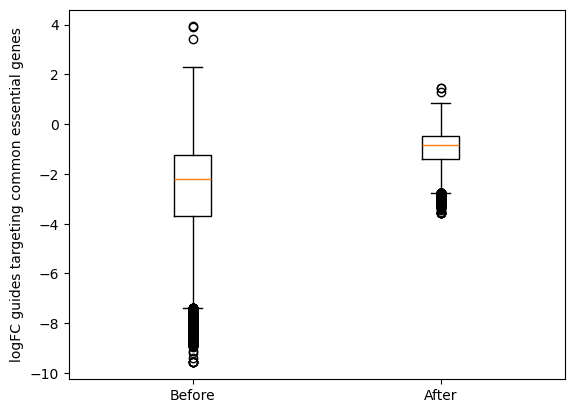

In [152]:
# check whether the normalization works (the median of lfc data should be around 0)
sanity_check_scale_essential(sgrna_lfc, sgrna_lfc_scaled, list_common_essential)

In [153]:
# averaged sgRNA LFC across replicates
lfc_norm_scaled_avg = mean_row(sgrna_lfc_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.302955
1,sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-1.048763
2,sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.529674
3,sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,-0.189771
4,sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.738266
...,...,...,...,...
70056,sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.210840
70057,sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,-0.189352
70058,sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.361049
70059,sgluciferase_8,CTATTCTGATTACACCCGAG,luciferase,-0.014003


In [154]:
lfc_norm_scaled_avg.to_csv("./output_normalized/tkov3_rpe1_normalized_lfc.csv", index=False)